# DXC09 Tier-2 Data Visualization Notebook

This notebook is for **exploratory data visualization** on:

`DXC09_Industrial_Tier2CompetitionData20090330`

It uses the same general dataset-loading idea as your earlier notebook:
- custom DXC time parsing
- a `DXC09Tier2Loader`
- scenario-wise loading

Then it adds a full visualization layer for:
- dataset overview
- scenario lengths and sample rates
- time-series plots
- missingness
- sensor distributions
- normal vs faulty comparisons
- correlation heatmaps
- baseline-zscore heatmaps
- event/evidence counts

In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Any, List, Optional, Tuple

import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

## 1) Configuration

Update `DATASET_ROOT` if needed.

You can also edit:
- how many scenarios to scan in summary mode
- which scenario to visualize in detail
- how many sensors to show in comparison plots

In [2]:
DATASET_ROOT = Path(r"../../data/DXC09_Industrial_Tier2CompetitionData20090330")

DEFAULT_SCENARIO_ID = None   # set manually, e.g. "Exp_727_pb_t2"
MAX_SCENARIOS_FOR_OVERVIEW = None   # None = scan all
TOP_SENSORS_FOR_COMPARISON = 12
TOP_SENSORS_FOR_HEATMAP = 20
WINDOW_FOR_ROLLING = 10

## 2) Time parser

Supports timestamp strings like:
- `2009-02-27 13:44:01.061 GMT-08:00`
- `Feb 27 2009 13:44:01.061 GMT-08`

In [3]:
MONTHS = {"jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,"jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12}

ISO_RE = re.compile(
    r"^(?P<y>\d{4})-(?P<mo>\d{2})-(?P<d>\d{2})\s+"
    r"(?P<h>\d{2}):(?P<mi>\d{2}):(?P<s>\d{2})\.(?P<ms>\d{1,6})"
    r"(?:\s+GMT(?P<tzsign>[+-])(?P<tzh>\d{2}):(?P<tzm>\d{2}))?$"
)

MON_RE = re.compile(
    r"^(?P<mon>[A-Za-z]{3})\s+(?P<day>\d{1,2})\s+(?P<year>\d{4})\s+"
    r"(?P<h>\d{2}):(?P<mi>\d{2}):(?P<s>\d{2})\.(?P<ms>\d{1,6})"
    r"(?:\s+GMT(?P<tzsign>[+-])(?P<tzh>\d{2})(?::?(?P<tzm>\d{2}))?)?$"
)

def parse_dxc_time_series(ts: pd.Series) -> pd.DatetimeIndex:
    vals = ts.astype(str).str.replace(r"\s+", " ", regex=True).str.strip().tolist()
    out = []
    for v in vals:
        m = ISO_RE.match(v)
        if m:
            y = int(m.group("y")); mo = int(m.group("mo")); d = int(m.group("d"))
            h = int(m.group("h")); mi = int(m.group("mi")); s = int(m.group("s"))
            us = int(m.group("ms").ljust(6, "0")[:6])
            out.append(pd.Timestamp(y, mo, d, h, mi, s, us))
            continue

        m = MON_RE.match(v)
        if m:
            mo = MONTHS[m.group("mon").lower()]
            d = int(m.group("day")); y = int(m.group("year"))
            h = int(m.group("h")); mi = int(m.group("mi")); s = int(m.group("s"))
            us = int(m.group("ms").ljust(6, "0")[:6])
            out.append(pd.Timestamp(y, mo, d, h, mi, s, us))
            continue

        out.append(pd.NaT)

    idx = pd.DatetimeIndex(out)
    frac_bad = pd.isna(idx).mean()
    if frac_bad > 0.01:
        examples = [vals[i] for i, x in enumerate(idx) if pd.isna(x)][:5]
        raise ValueError(f"Time parsing failed for {frac_bad:.1%} rows. Examples: {examples}")
    return idx

## 3) Scenario loader

In [4]:
@dataclass
class Scenario:
    scenario_id: str
    X: pd.DataFrame
    meta: Dict[str, Any]

class DXC09Tier2Loader:
    def __init__(self, root: Path):
        self.root = Path(root)
        self.files = sorted(self.root.glob("Exp_*_pb_t2*.txt"))
        if not self.files:
            raise FileNotFoundError(f"No Tier-2 files found in: {self.root}")

    def list_scenarios(self) -> List[str]:
        return [f.stem for f in self.files]

    def load_scenario(self, scenario_id: str) -> Scenario:
        path = self.root / f"{scenario_id}.txt"
        if not path.exists():
            raise FileNotFoundError(path)

        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            lines = f.readlines()

        meta = {"path": str(path)}
        for line in lines:
            if line.startswith("ExperimentControl"):
                meta["ExperimentControlLine"] = line.strip()

        header_idx = None
        for i, line in enumerate(lines):
            if line.startswith("SensorData"):
                header_idx = i
                break
        if header_idx is None:
            raise ValueError(f"SensorData header not found in {path.name}")

        headers = lines[header_idx].strip().split("\t")

        rows = []
        for line in lines[header_idx + 1:]:
            parts = line.rstrip("\n").split("\t")
            if len(parts) == len(headers):
                rows.append(parts)

        df = pd.DataFrame(rows, columns=headers)
        df = df.drop(columns=["SensorData"], errors="ignore")

        if "Time" not in df.columns:
            raise ValueError(f"Time column not found in {path.name}")

        idx = parse_dxc_time_series(df["Time"])
        df = df.drop(columns=["Time"])
        df.index = idx
        df.index.name = "time"
        df = df.sort_index()

        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

        df = df.dropna(axis=1, how="all")

        if df.index.duplicated().any():
            df = df[~df.index.duplicated(keep="last")]

        return Scenario(scenario_id=scenario_id, X=df, meta=meta)

## 4) Utilities

In [5]:
def scenario_is_faulty(scenario_id: str) -> int:
    sid = scenario_id.lower()
    return int(("_t2f" in sid) or sid.endswith("t2f"))

def infer_sampling_stats(index: pd.DatetimeIndex) -> Dict[str, float]:
    if len(index) < 2:
        return {
            "median_dt_seconds": np.nan,
            "std_dt_seconds": np.nan,
            "duration_seconds": 0.0
        }
    dt = np.diff(index.view("i8")) / 1e9
    duration = (index.max() - index.min()).total_seconds()
    return {
        "median_dt_seconds": float(np.nanmedian(dt)),
        "std_dt_seconds": float(np.nanstd(dt)),
        "duration_seconds": float(duration)
    }

def get_constant_sensors(df: pd.DataFrame, std_eps: float = 1e-10) -> List[str]:
    constant_cols = []
    for c in df.columns:
        vals = df[c].dropna()
        if len(vals) <= 1:
            continue
        if float(vals.std()) <= std_eps:
            constant_cols.append(c)
    return constant_cols

def build_dataset_overview(loader: DXC09Tier2Loader, max_scenarios: Optional[int] = None) -> pd.DataFrame:
    rows = []
    scenario_ids = loader.list_scenarios()
    if max_scenarios is not None:
        scenario_ids = scenario_ids[:max_scenarios]

    for sid in scenario_ids:
        sc = loader.load_scenario(sid)
        stats = infer_sampling_stats(sc.X.index)
        rows.append({
            "scenario_id": sid,
            "is_faulty": scenario_is_faulty(sid),
            "n_rows": len(sc.X),
            "n_sensors": sc.X.shape[1],
            "start_time": sc.X.index.min(),
            "end_time": sc.X.index.max(),
            "duration_seconds": stats["duration_seconds"],
            "median_dt_seconds": stats["median_dt_seconds"],
            "std_dt_seconds": stats["std_dt_seconds"],
            "missing_ratio": float(sc.X.isna().mean().mean()),
            "constant_sensor_count": len(get_constant_sensors(sc.X)),
        })
    return pd.DataFrame(rows).sort_values(["is_faulty", "scenario_id"]).reset_index(drop=True)

def compute_baseline(loader: DXC09Tier2Loader, sensors: List[str]) -> Dict[str, Dict[str, float]]:
    vals = {s: [] for s in sensors}
    for sid in loader.list_scenarios():
        if scenario_is_faulty(sid):
            continue
        sc = loader.load_scenario(sid)
        X = sc.X[sensors].copy().ffill().bfill()
        for s in sensors:
            if s in X.columns:
                vals[s].append(X[s].values)

    baseline = {}
    for s, arrs in vals.items():
        if not arrs:
            continue
        x = np.concatenate(arrs)
        baseline[s] = {
            "mean": float(np.nanmean(x)),
            "std": float(np.nanstd(x) + 1e-6),
            "median": float(np.nanmedian(x)),
            "iqr": float(np.nanpercentile(x, 75) - np.nanpercentile(x, 25) + 1e-6),
        }
    return baseline

def top_variable_sensors(df: pd.DataFrame, top_n: int = 12) -> List[str]:
    s = df.std(numeric_only=True).sort_values(ascending=False)
    return s.head(top_n).index.tolist()

def compute_robust_zscores(df: pd.DataFrame, baseline: Dict[str, Dict[str, float]]) -> pd.DataFrame:
    Z = pd.DataFrame(index=df.index)
    for col in df.columns:
        if col not in baseline:
            continue
        center = baseline[col]["median"]
        scale = baseline[col]["iqr"]
        Z[col] = (df[col] - center) / (scale if scale > 1e-12 else 1.0)
    return Z

def build_evidence_matrix_tier2(
    X: pd.DataFrame,
    baseline: Dict[str, Dict[str, float]],
    z_hi: float = 2.0,
    use_robust: bool = True
) -> pd.DataFrame:
    X_filled = X.copy().ffill().bfill()
    E = {}
    for col in X_filled.columns:
        if col not in baseline:
            E[col] = pd.Series(["OK"] * len(X_filled), index=X_filled.index)
            continue

        if use_robust:
            center = baseline[col]["median"]
            scale = baseline[col]["iqr"]
        else:
            center = baseline[col]["mean"]
            scale = baseline[col]["std"]

        scale = scale if scale > 1e-12 else 1.0
        z = (X_filled[col] - center) / scale

        state = pd.Series("OK", index=X_filled.index)
        state[z >= z_hi] = "HIGH"
        state[z <= -z_hi] = "LOW"
        E[col] = state

    return pd.DataFrame(E, index=X_filled.index)

## 5) Load dataset

In [6]:
loader = DXC09Tier2Loader(DATASET_ROOT)
scenario_ids = loader.list_scenarios()
len(scenario_ids), scenario_ids[:10]

(120,
 ['Exp_727_pb_t2',
  'Exp_728_pb_t2',
  'Exp_729_pb_t2',
  'Exp_730_pb_t2',
  'Exp_731_pb_t2',
  'Exp_732_pb_t2',
  'Exp_732_pb_t2f',
  'Exp_733_pb_t2',
  'Exp_733_pb_t2f',
  'Exp_734_pb_t2'])

## 6) Dataset overview table

In [7]:
overview = build_dataset_overview(loader, max_scenarios=MAX_SCENARIOS_FOR_OVERVIEW)
overview.head()

,scenario_id,is_faulty,n_rows,n_sensors,start_time,end_time,duration_seconds,median_dt_seconds,std_dt_seconds,missing_ratio,constant_sensor_count
0,Exp_727_pb_t2,0,480,83,2009-02-27 13:44:01.061,2009-02-27 13:48:00.564,239.503,0.5,0.000079,0.0,15
1,Exp_728_pb_t2,0,481,83,2009-02-27 13:59:00.572,2009-02-27 14:03:00.575,240.003,0.5,0.000079,0.0,15
2,Exp_729_pb_t2,0,481,83,2009-02-27 14:14:00.583,2009-02-27 14:18:00.586,240.003,0.5,0.000079,0.0,15
3,Exp_730_pb_t2,0,481,83,2009-02-27 14:29:00.594,2009-02-27 14:33:00.597,240.003,0.5,0.000079,0.0,15
4,Exp_731_pb_t2,0,481,83,2009-02-27 14:44:00.606,2009-02-27 14:48:00.609,240.003,0.5,0.000079,0.0,15


## 7) Dataset-level overview plots

Total scenarios: 120
Normal scenarios: 69
Faulty scenarios: 51
Median rows per scenario: 481.0
Median sensors per scenario: 83.0
Median duration (s): 240.003
Median dt (s): 0.5


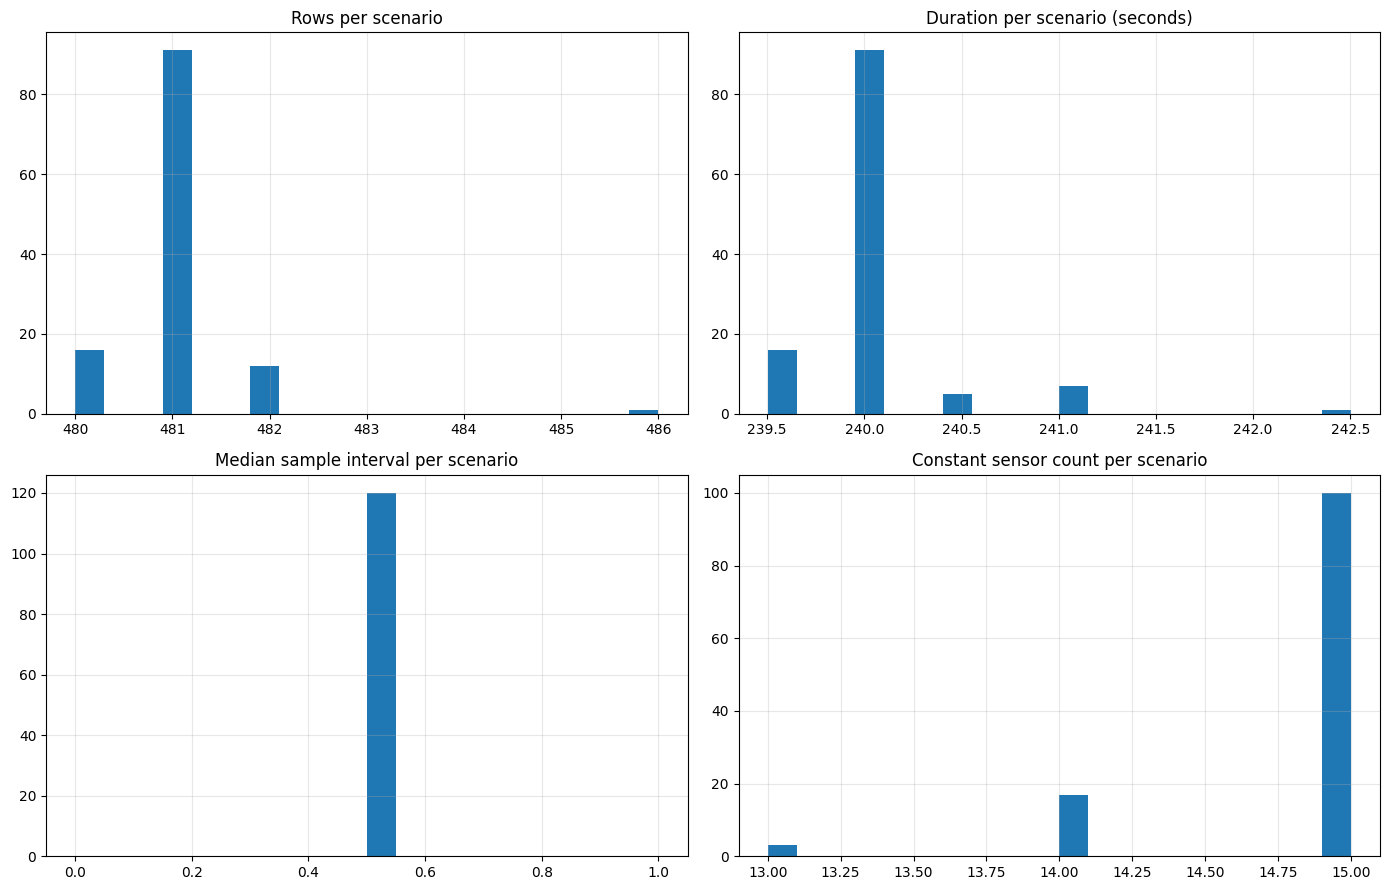

In [8]:
print("Total scenarios:", len(overview))
print("Normal scenarios:", int((overview["is_faulty"] == 0).sum()))
print("Faulty scenarios:", int((overview["is_faulty"] == 1).sum()))
print("Median rows per scenario:", float(overview["n_rows"].median()))
print("Median sensors per scenario:", float(overview["n_sensors"].median()))
print("Median duration (s):", float(overview["duration_seconds"].median()))
print("Median dt (s):", float(overview["median_dt_seconds"].median()))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

overview["n_rows"].hist(ax=axes[0, 0], bins=20)
axes[0, 0].set_title("Rows per scenario")

overview["duration_seconds"].hist(ax=axes[0, 1], bins=20)
axes[0, 1].set_title("Duration per scenario (seconds)")

overview["median_dt_seconds"].hist(ax=axes[1, 0], bins=20)
axes[1, 0].set_title("Median sample interval per scenario")

overview["constant_sensor_count"].hist(ax=axes[1, 1], bins=20)
axes[1, 1].set_title("Constant sensor count per scenario")

for ax in axes.ravel():
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8) Compare normal vs faulty scenario lengths

In [9]:
grouped = overview.groupby("is_faulty")[["n_rows", "duration_seconds", "missing_ratio", "constant_sensor_count"]].agg(["mean", "median"])
grouped

n_rows        duration_seconds          missing_ratio        constant_sensor_count       
                 mean median             mean   median          mean median                  mean median
is_faulty                                                                                               
0          481.000000  481.0       240.032014  240.003           0.0    0.0             14.884058   15.0
1          481.019608  481.0       240.042275  240.003           0.0    0.0             14.705882   15.0

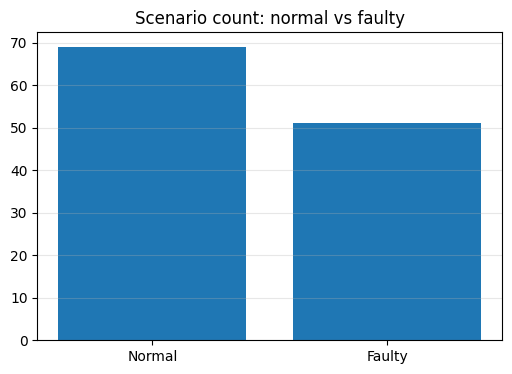

In [10]:
fault_counts = overview["is_faulty"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["Normal", "Faulty"], [fault_counts.get(0, 0), fault_counts.get(1, 0)])
plt.title("Scenario count: normal vs faulty")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 9) Choose a scenario for detailed visualization

In [11]:
selected_scenario_id = DEFAULT_SCENARIO_ID or scenario_ids[0]
sc = loader.load_scenario(selected_scenario_id)

print("Scenario:", sc.scenario_id)
print("Faulty:", bool(scenario_is_faulty(sc.scenario_id)))
print("Shape:", sc.X.shape)
print("Time range:", sc.X.index.min(), "to", sc.X.index.max())
print("Missing ratio:", float(sc.X.isna().mean().mean()))
print("Constant sensors:", len(get_constant_sensors(sc.X)))
sc.X.head()

Scenario: Exp_727_pb_t2
Faulty: False
Shape: (480, 83)
Time range: 2009-02-27 13:44:01.061000 to 2009-02-27 13:48:00.564000
Missing ratio: 0.0
Constant sensors: 15


,E135,E140,E142,E161,E165,E167,E181,E235,E240,E242,E261,E265,E267,E281,E335,E340,ESH141A,ESH144A,ESH160A,ESH170,ESH171,ESH172,ESH173,ESH174,ESH175,ESH183,ESH184,ESH241A,ESH244A,ESH260A,ESH270,ESH271,ESH272,ESH273,ESH274,ESH275,ESH283,ESH284,ESH341A,ESH344A,FT520,FT525,ISH136,ISH162,ISH166,ISH180,ISH236,ISH262,ISH266,ISH280,ISH336,IT140,IT161,IT167,IT181,IT240,IT261,IT267,IT281,IT340,LT500,LT505,ST165,ST265,ST515,ST516,TE128,TE129,TE133,TE228,TE229,TE328,TE329,TE500,TE501,TE502,TE505,TE506,TE507,TE510,TE511,XT167,XT267
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2009-02-27 13:44:01.061,24.761730,24.761730,0.014649,0.029297,0.146487,0.073243,0.014649,24.878920,24.87892,0.000000,0.615244,0.292973,0.21973,0.615244,24.190434,24.190434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.064112,0.079752,0.000388,0.012118,-0.076653,-0.01409,-0.003523,0.000388,-0.045371,6.693539,9.610484,0.43946,0.43946,0.0,0.0,71.860382,70.447243,71.283592,71.773865,72.956284,73.186996,72.725563,71.562808,70.999184,69.966171,71.487853,71.571683,70.953385,72.245410,68.246174,-48.655412,-43.024832
2009-02-27 13:44:01.561,24.747082,24.761730,0.000000,0.029297,0.146487,0.073243,0.014649,24.893568,24.87892,0.000000,0.600595,0.292973,0.21973,0.615244,24.190434,24.175783,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.048472,0.079752,-0.007433,0.008208,-0.076653,-0.01409,0.000388,0.000388,-0.045371,6.695117,9.529078,0.21973,0.43946,0.0,0.0,71.860382,70.447243,71.341270,71.745018,72.956284,73.186996,72.725563,71.560352,71.000983,69.970208,71.485031,71.567670,70.956324,72.251639,68.252763,-43.362664,-48.824328
2009-02-27 13:44:02.061,24.747082,24.761730,0.000000,0.014649,0.073243,0.073243,0.014649,24.893568,24.87892,0.000000,0.600595,0.219730,0.21973,0.600595,24.190434,24.190434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.064112,0.079752,-0.007433,0.012118,-0.061011,-0.01409,0.000388,0.000388,-0.045371,6.704981,9.619295,0.21973,0.43946,0.0,0.0,71.860382,70.447243,71.341270,71.745018,72.956284,73.215836,72.783249,71.551180,70.999324,69.966925,71.487702,71.575101,70.954653,72.250361,68.251328,-43.250053,-45.783819
2009-02-27 13:44:02.561,24.761730,24.776379,0.043946,0.029297,0.146487,0.073243,0.014649,24.878920,24.87892,0.043946,0.600595,0.219730,0.21973,0.600595,24.190434,24.190434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.064112,0.079752,-0.003523,0.012118,-0.045371,-0.01409,-0.003523,0.000388,-0.045371,6.527570,9.546437,0.21973,0.43946,0.0,0.0,71.860382,70.476082,71.283592,71.745018,72.956284,73.215836,72.783249,71.548669,70.994792,69.965620,71.485712,71.569730,70.954024,72.240716,68.253056,-57.161105,-56.541740
2009-02-27 13:44:03.061,24.761730,24.761730,0.000000,0.029297,0.073243,0.146487,0.014649,24.878920,24.87892,0.000000,0.585946,0.292973,0.21973,0.600595,24.190434,24.190434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.064112,0.079752,-0.003523,0.012118,-0.061011,-0.01409,0.008208,0.000388,-0.045371,6.608714,9.525264,0.21973,0.65919,0.0,0.0,71.860382,70.476082,71.283592,71.773865,72.956284,73.215836,72.754410,71.546638,70.996079,69.966753,71.484184,71.567805,70.953008,72.237920,68.251571,-35.701563,-45.108143


## 10) Most variable sensors in this scenario

In [12]:
selected_sensors = top_variable_sensors(sc.X, top_n=12)
selected_sensors

['ST516',
 'ST515',
 'TE511',
 'TE510',
 'ST165',
 'FT520',
 'ST265',
 'FT525',
 'E267',
 'E265',
 'TE506',
 'TE500']

## 11) Raw time-series plots for top variable sensors

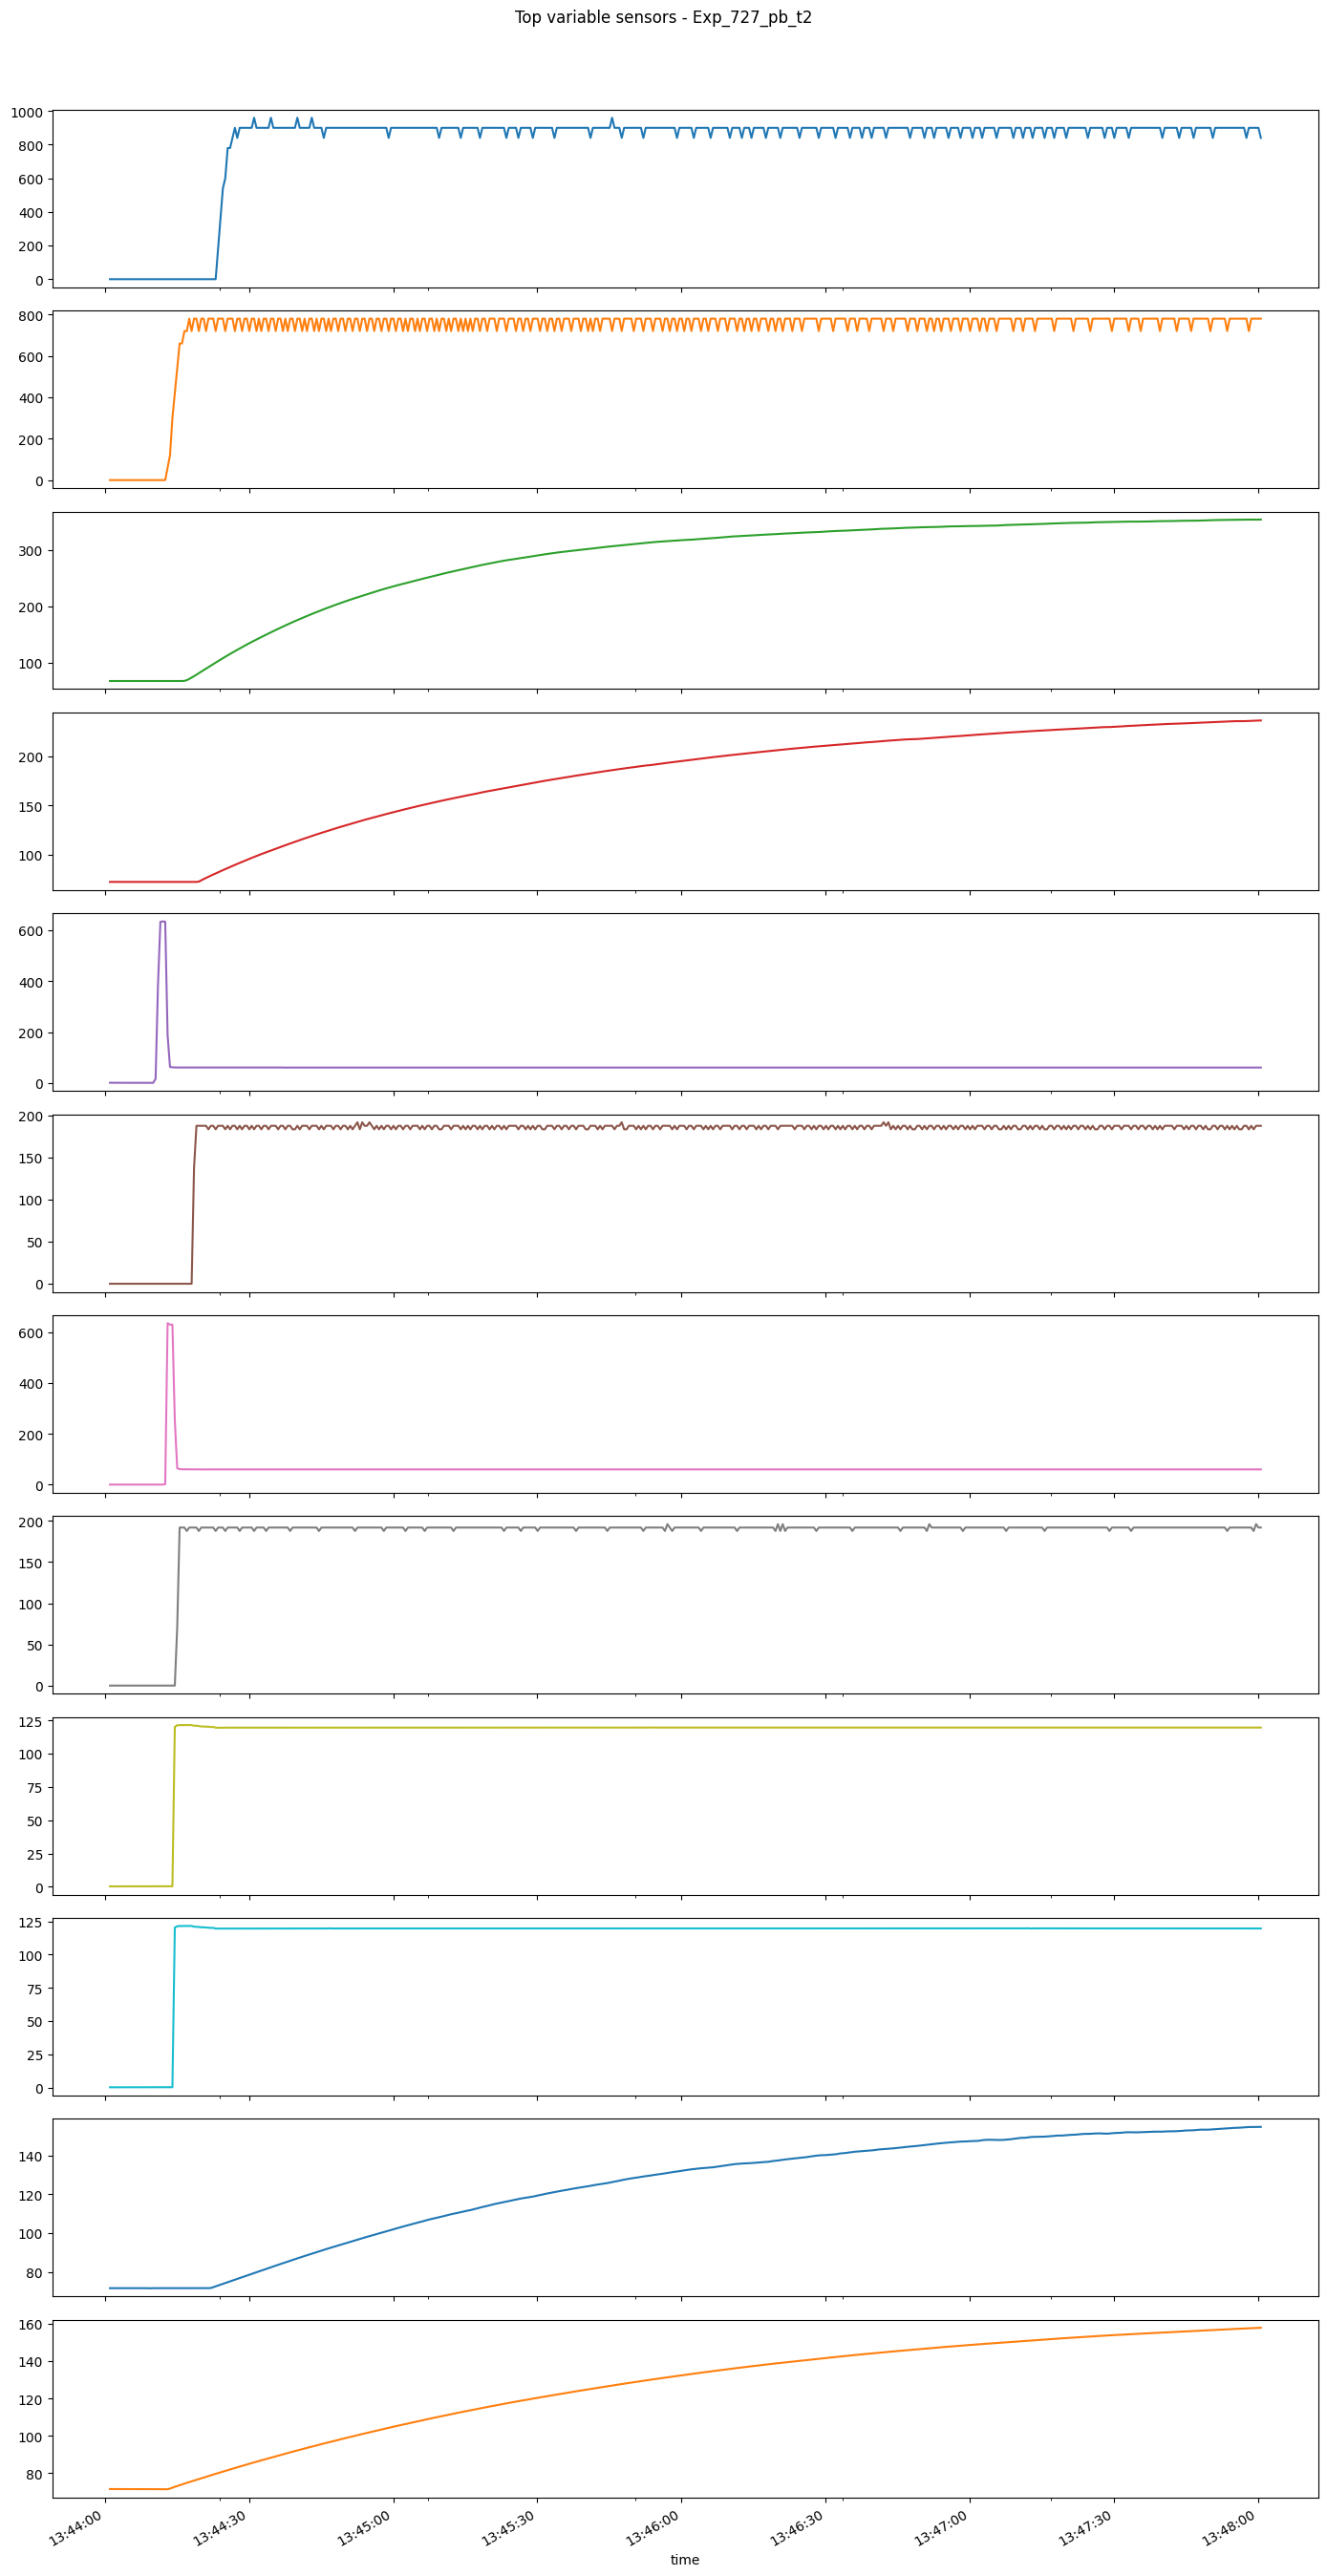

In [13]:
sc.X[selected_sensors].plot(subplots=True, figsize=(14, 2.2 * len(selected_sensors)), sharex=True, legend=False)
plt.suptitle(f"Top variable sensors - {sc.scenario_id}", y=1.02)
plt.tight_layout()
plt.show()

## 12) Rolling-smoothed trends for the same sensors

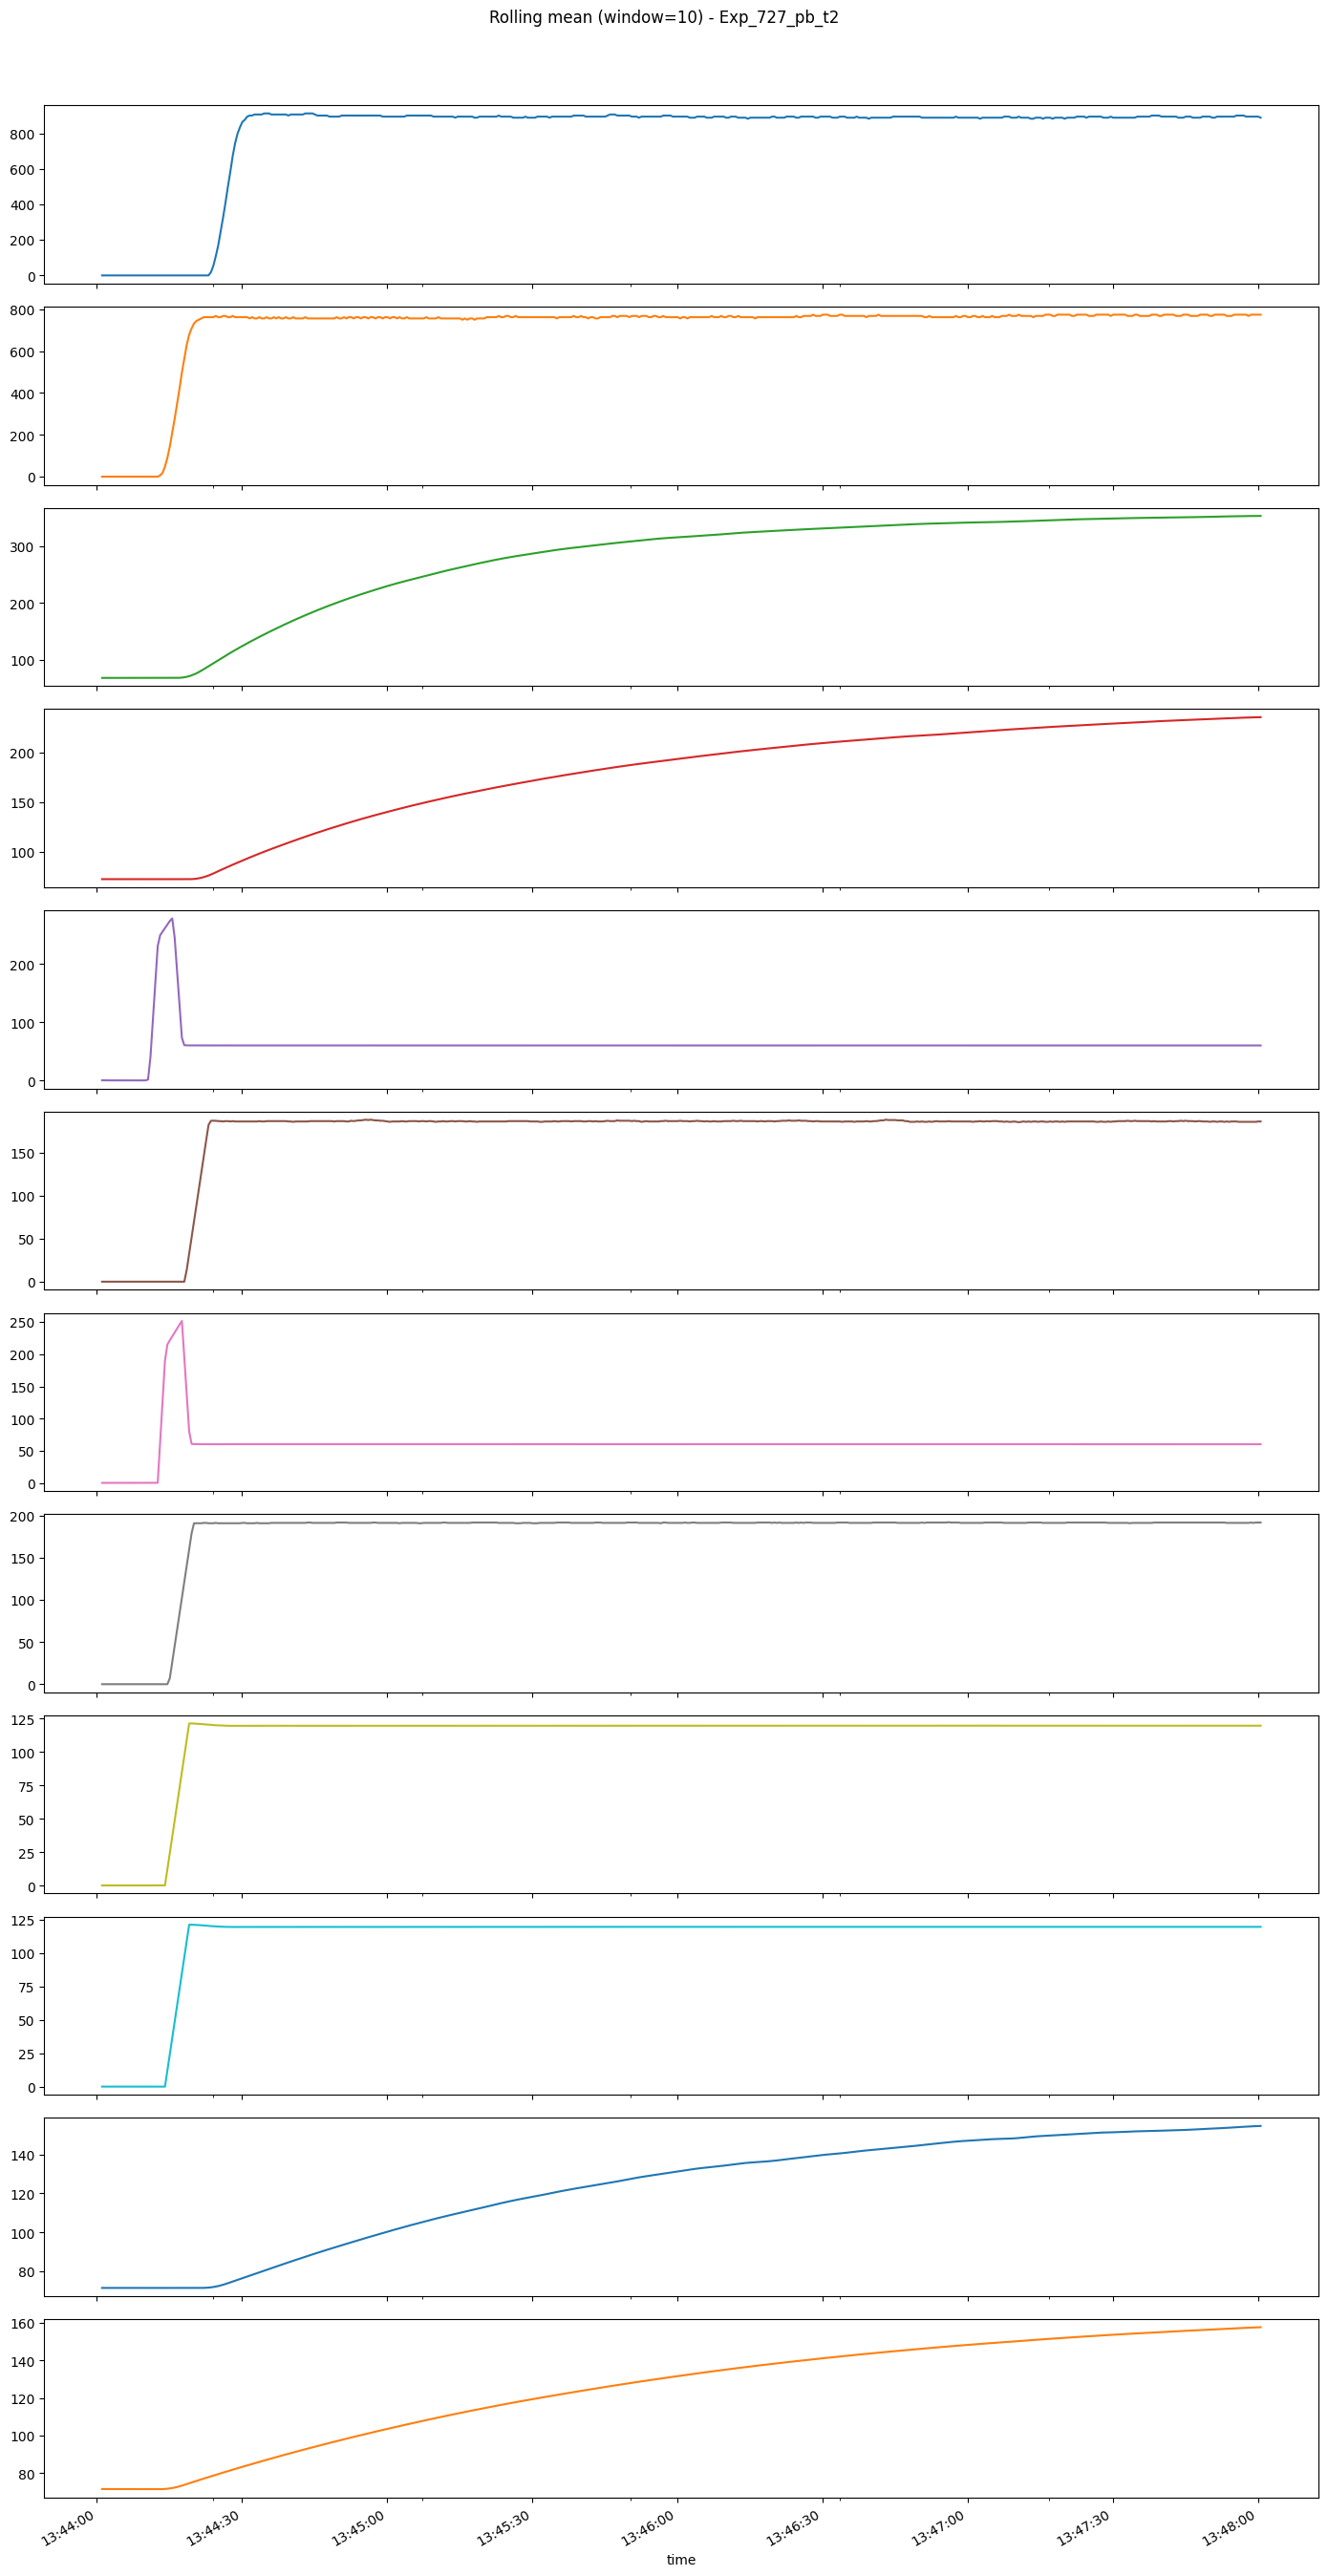

In [14]:
rolled = sc.X[selected_sensors].rolling(WINDOW_FOR_ROLLING, min_periods=1).mean()
rolled.plot(subplots=True, figsize=(14, 2.2 * len(selected_sensors)), sharex=True, legend=False)
plt.suptitle(f"Rolling mean (window={WINDOW_FOR_ROLLING}) - {sc.scenario_id}", y=1.02)
plt.tight_layout()
plt.show()

## 13) Missingness by sensor in the selected scenario

In [15]:
missing_by_sensor = sc.X.isna().mean().sort_values(ascending=False)
missing_by_sensor.head(20)

E135       0.0
E140       0.0
E142       0.0
E161       0.0
E165       0.0
E167       0.0
E181       0.0
E235       0.0
E240       0.0
E242       0.0
E261       0.0
E265       0.0
E267       0.0
E281       0.0
E335       0.0
E340       0.0
ESH141A    0.0
ESH144A    0.0
ESH160A    0.0
ESH170     0.0
dtype: float64

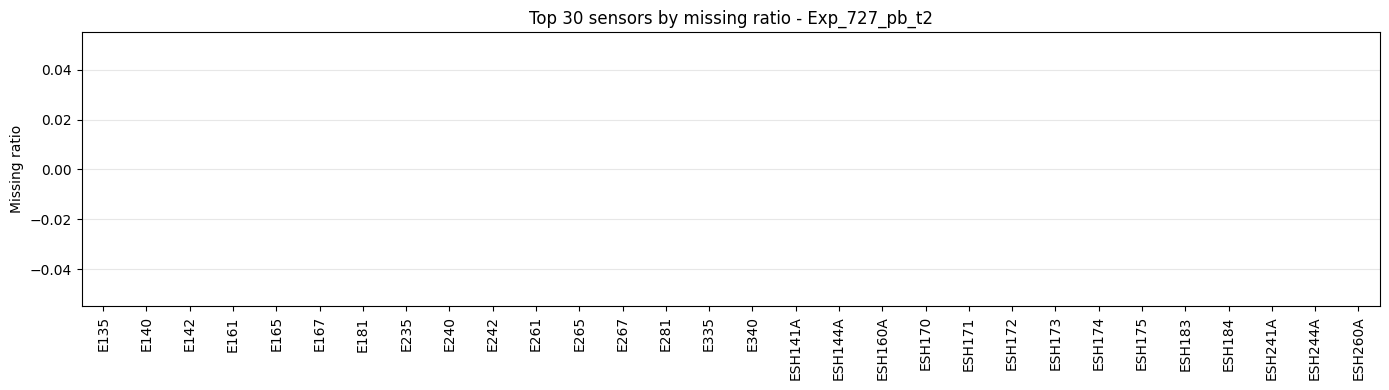

In [16]:
plt.figure(figsize=(14, 4))
missing_by_sensor.head(30).plot(kind="bar")
plt.title(f"Top 30 sensors by missing ratio - {sc.scenario_id}")
plt.ylabel("Missing ratio")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 14) Missingness / value heatmap for selected sensors

This helps you spot:
- block missingness
- flatline behavior
- abrupt transitions

C:\Users\dangw\AppData\Local\Temp\ipykernel_30584\150277698.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  heatmap_sensors = top_variable_sensors(sc.X.fillna(method="ffill").fillna(method="bfill"), top_n=TOP_SENSORS_FOR_HEATMAP)


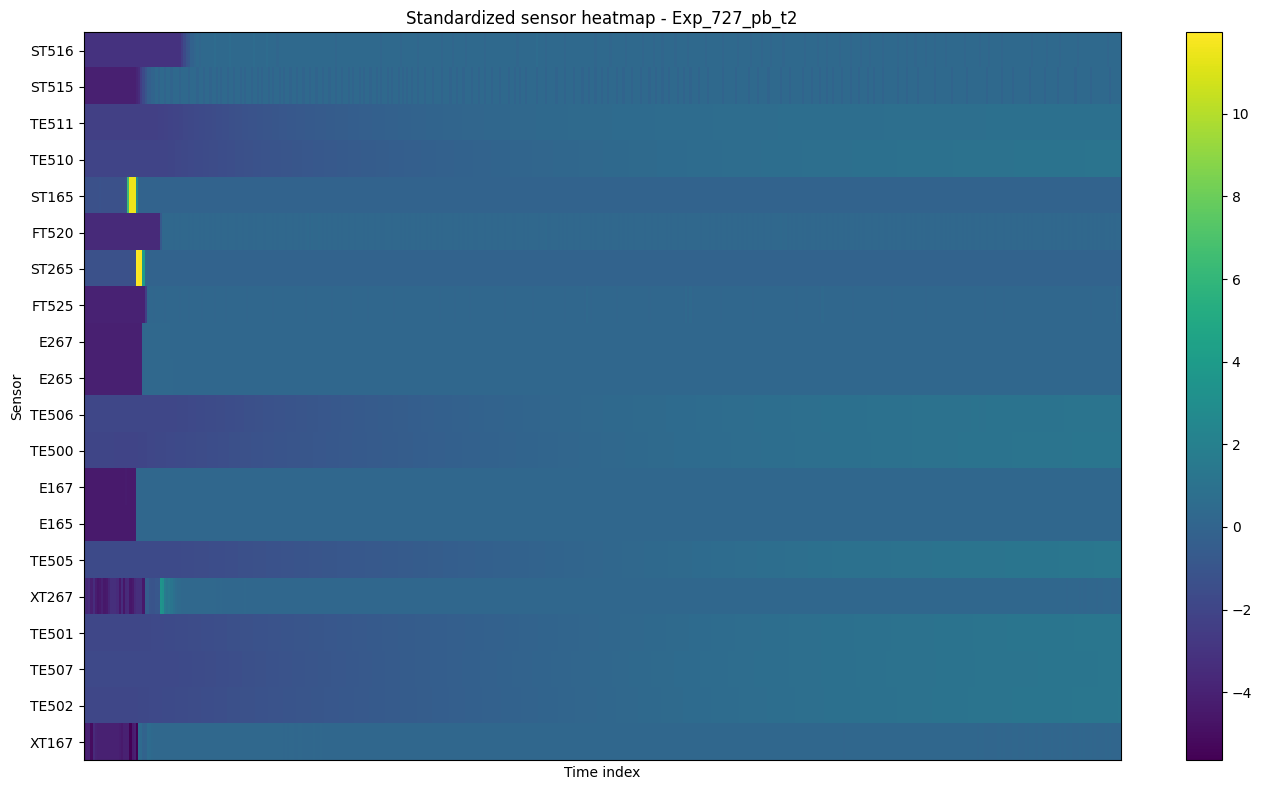

In [17]:
heatmap_sensors = top_variable_sensors(sc.X.fillna(method="ffill").fillna(method="bfill"), top_n=TOP_SENSORS_FOR_HEATMAP)
Xh = sc.X[heatmap_sensors].copy()

# standardize per sensor for visualization only
Xh = (Xh - Xh.mean()) / (Xh.std() + 1e-9)
Xh = Xh.fillna(0.0)

plt.figure(figsize=(14, 8))
plt.imshow(Xh.T.values, aspect="auto", interpolation="nearest")
plt.yticks(range(len(heatmap_sensors)), heatmap_sensors)
plt.xticks([])
plt.title(f"Standardized sensor heatmap - {sc.scenario_id}")
plt.xlabel("Time index")
plt.ylabel("Sensor")
plt.colorbar()
plt.tight_layout()
plt.show()

## 15) Correlation heatmap for selected sensors

C:\Users\dangw\AppData\Local\Temp\ipykernel_30584\1182789187.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  corr_sensors = top_variable_sensors(sc.X.fillna(method="ffill").fillna(method="bfill"), top_n=min(20, sc.X.shape[1]))


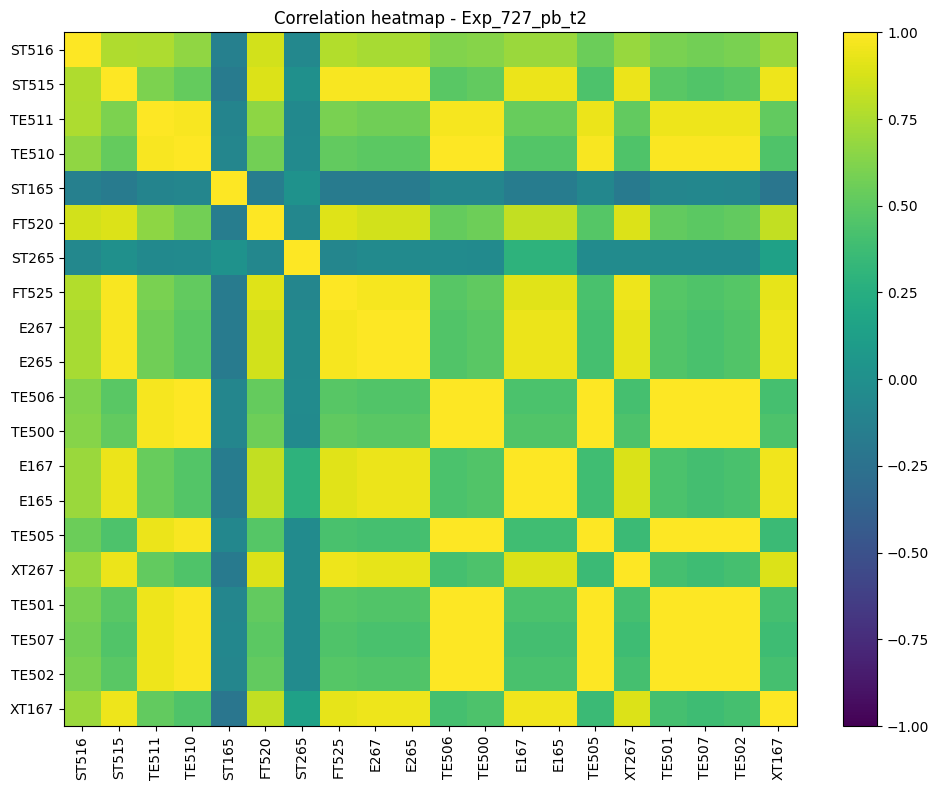

In [18]:
corr_sensors = top_variable_sensors(sc.X.fillna(method="ffill").fillna(method="bfill"), top_n=min(20, sc.X.shape[1]))
corr = sc.X[corr_sensors].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto", interpolation="nearest", vmin=-1, vmax=1)
plt.xticks(range(len(corr_sensors)), corr_sensors, rotation=90)
plt.yticks(range(len(corr_sensors)), corr_sensors)
plt.title(f"Correlation heatmap - {sc.scenario_id}")
plt.colorbar()
plt.tight_layout()
plt.show()

## 16) Baseline vs scenario deviation heatmap

Baseline is built from **normal** scenarios only.

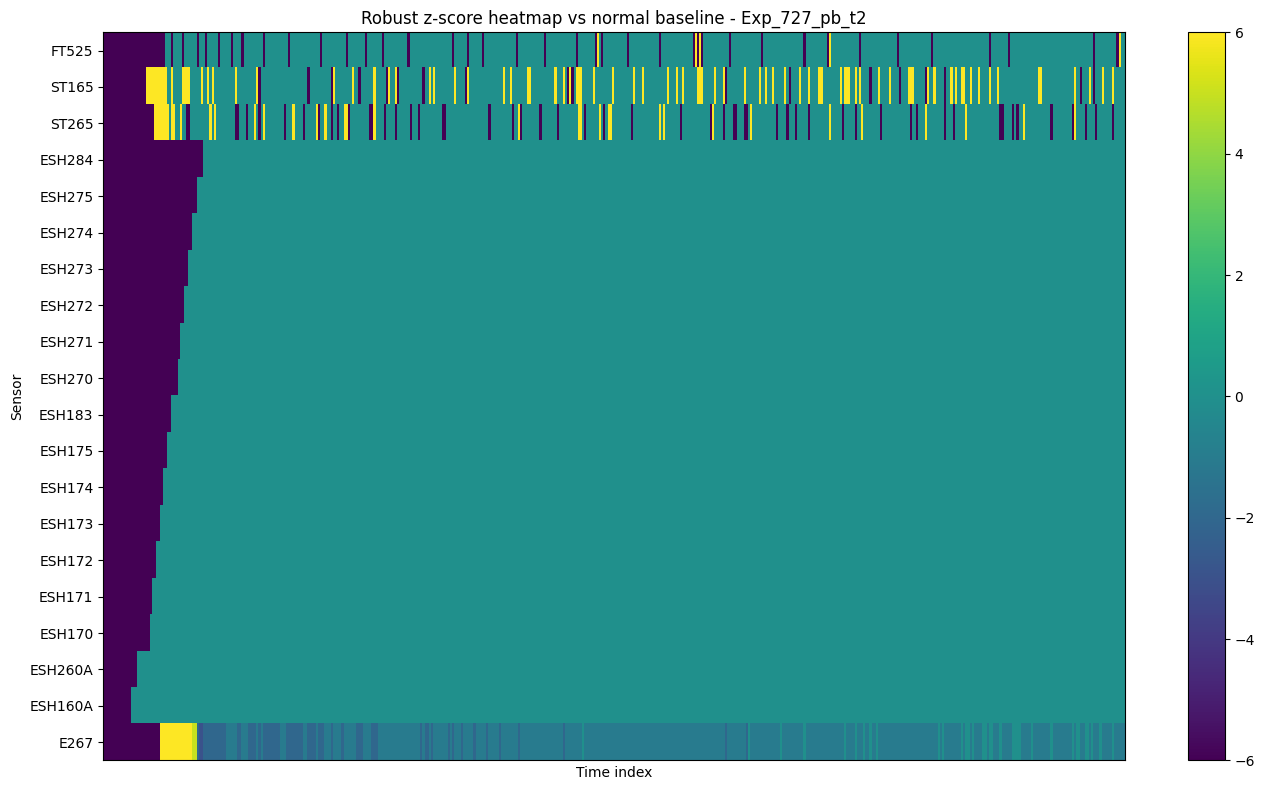

In [19]:
baseline = compute_baseline(loader, list(sc.X.columns))
Z = compute_robust_zscores(sc.X.copy().ffill().bfill(), baseline)

z_sensors = Z.abs().mean().sort_values(ascending=False).head(TOP_SENSORS_FOR_HEATMAP).index.tolist()
Zh = Z[z_sensors].clip(-6, 6)

plt.figure(figsize=(14, 8))
plt.imshow(Zh.T.values, aspect="auto", interpolation="nearest", vmin=-6, vmax=6)
plt.yticks(range(len(z_sensors)), z_sensors)
plt.xticks([])
plt.title(f"Robust z-score heatmap vs normal baseline - {sc.scenario_id}")
plt.xlabel("Time index")
plt.ylabel("Sensor")
plt.colorbar()
plt.tight_layout()
plt.show()

## 17) Normal vs faulty comparison at sensor level

This section compares sensor behavior across scenarios using:
- scenario mean
- scenario std
- absolute z-shift from normal baseline

In [20]:
records = []
all_scenarios = loader.list_scenarios()

for sid in all_scenarios:
    scc = loader.load_scenario(sid)
    Xc = scc.X.copy().ffill().bfill()
    for sensor in Xc.columns:
        vals = Xc[sensor].dropna().values
        if len(vals) == 0:
            continue
        records.append({
            "scenario_id": sid,
            "is_faulty": scenario_is_faulty(sid),
            "sensor": sensor,
            "mean": float(np.nanmean(vals)),
            "std": float(np.nanstd(vals)),
        })

sensor_summary = pd.DataFrame(records)
sensor_summary.head()

,scenario_id,is_faulty,sensor,mean,std
0,Exp_727_pb_t2,0,E135,23.803830,0.234735
1,Exp_727_pb_t2,0,E140,23.478874,0.311753
2,Exp_727_pb_t2,0,E142,22.792435,3.808317
3,Exp_727_pb_t2,0,E161,22.753769,3.799993
4,Exp_727_pb_t2,0,E165,113.440148,25.997036


In [21]:
normal_means = sensor_summary[sensor_summary["is_faulty"] == 0].groupby("sensor")["mean"].mean()
faulty_means = sensor_summary[sensor_summary["is_faulty"] == 1].groupby("sensor")["mean"].mean()

delta_mean = (faulty_means - normal_means).abs().sort_values(ascending=False)
top_compare_sensors = delta_mean.head(TOP_SENSORS_FOR_COMPARISON).index.tolist()
delta_mean.head(20)

sensor
ST515    15.752830
ST516    13.174901
TE510     4.351152
E167      2.705375
TE506     2.509272
FT525     2.354515
TE511     2.279376
FT520     1.884125
E165      1.525468
ST265     1.524914
ST165     1.351173
E265      1.168601
TE505     1.042363
LT500     0.813128
IT140     0.734719
E281      0.703172
TE507     0.616751
TE133     0.610603
XT167     0.568127
TE502     0.555361
Name: mean, dtype: float64

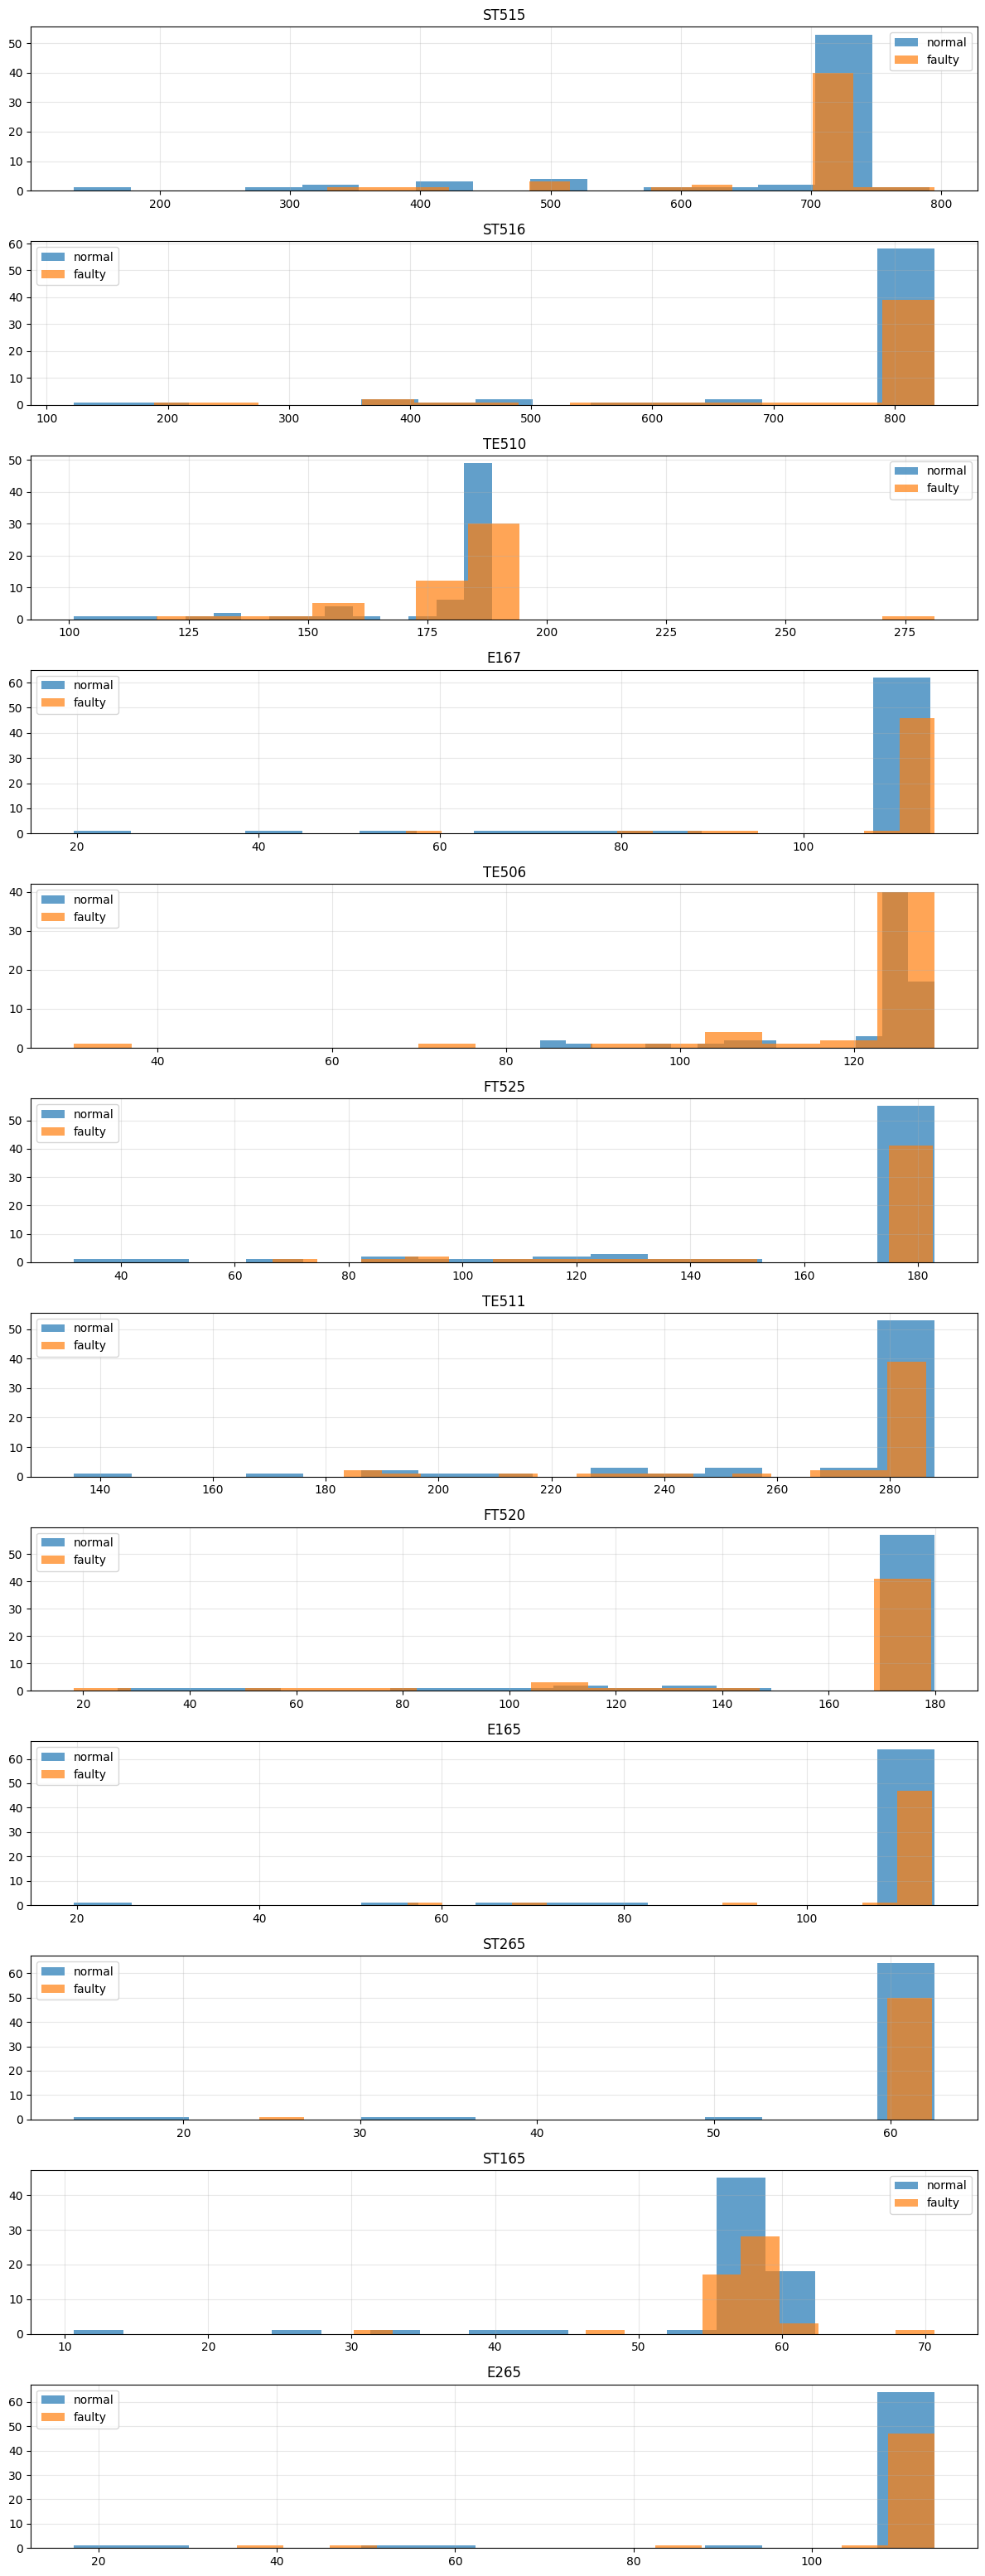

In [22]:
cmp = sensor_summary[sensor_summary["sensor"].isin(top_compare_sensors)].copy()

fig, axes = plt.subplots(len(top_compare_sensors), 1, figsize=(12, 2.6 * len(top_compare_sensors)), sharex=False)
if len(top_compare_sensors) == 1:
    axes = [axes]

for ax, sensor in zip(axes, top_compare_sensors):
    dn = cmp[(cmp["sensor"] == sensor) & (cmp["is_faulty"] == 0)]["mean"].values
    df = cmp[(cmp["sensor"] == sensor) & (cmp["is_faulty"] == 1)]["mean"].values
    ax.hist(dn, bins=15, alpha=0.7, label="normal")
    ax.hist(df, bins=15, alpha=0.7, label="faulty")
    ax.set_title(sensor)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 18) Evidence-state visualization (LOW / OK / HIGH)

This is close to the logic from your previous notebook, but kept here for visualization.

In [23]:
E = build_evidence_matrix_tier2(sc.X, baseline, z_hi=2.0, use_robust=True)
E.head()

,E135,E140,E142,E161,E165,E167,E181,E235,E240,E242,E261,E265,E267,E281,E335,E340,ESH141A,ESH144A,ESH160A,ESH170,ESH171,ESH172,ESH173,ESH174,ESH175,ESH183,ESH184,ESH241A,ESH244A,ESH260A,ESH270,ESH271,ESH272,ESH273,ESH274,ESH275,ESH283,ESH284,ESH341A,ESH344A,FT520,FT525,ISH136,ISH162,ISH166,ISH180,ISH236,ISH262,ISH266,ISH280,ISH336,IT140,IT161,IT167,IT181,IT240,IT261,IT267,IT281,IT340,LT500,LT505,ST165,ST265,ST515,ST516,TE128,TE129,TE133,TE228,TE229,TE328,TE329,TE500,TE501,TE502,TE505,TE506,TE507,TE510,TE511,XT167,XT267
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2009-02-27 13:44:01.061,OK,OK,LOW,LOW,LOW,LOW,LOW,OK,OK,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,OK,LOW,LOW,LOW,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,LOW,LOW,LOW,LOW,LOW,LOW,LOW,OK,LOW,OK,OK,LOW,LOW,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,LOW,LOW,LOW,OK,LOW,LOW,LOW,OK,LOW,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,LOW,LOW
2009-02-27 13:44:01.561,OK,OK,LOW,LOW,LOW,LOW,LOW,OK,OK,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,OK,LOW,LOW,LOW,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,LOW,LOW,LOW,LOW,LOW,LOW,LOW,OK,LOW,OK,OK,LOW,LOW,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,LOW,LOW,LOW,OK,LOW,LOW,LOW,OK,LOW,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,LOW,LOW
2009-02-27 13:44:02.061,OK,OK,LOW,LOW,LOW,LOW,LOW,OK,OK,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,OK,LOW,LOW,LOW,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,LOW,LOW,LOW,LOW,LOW,LOW,LOW,OK,LOW,OK,OK,LOW,LOW,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,LOW,LOW,LOW,OK,LOW,LOW,LOW,OK,LOW,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,LOW,LOW
2009-02-27 13:44:02.561,OK,OK,LOW,LOW,LOW,LOW,LOW,OK,OK,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,OK,LOW,LOW,LOW,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,LOW,LOW,LOW,LOW,LOW,LOW,LOW,OK,LOW,OK,OK,LOW,LOW,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,LOW,LOW,LOW,OK,LOW,LOW,LOW,OK,LOW,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,LOW,LOW
2009-02-27 13:44:03.061,OK,OK,LOW,LOW,LOW,LOW,LOW,OK,OK,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,OK,LOW,LOW,LOW,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,LOW,LOW,LOW,LOW,LOW,LOW,LOW,OK,LOW,OK,OK,LOW,LOW,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,LOW,LOW,LOW,OK,LOW,LOW,LOW,OK,LOW,LOW,LOW,LOW,LOW,LOW,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,LOW,LOW


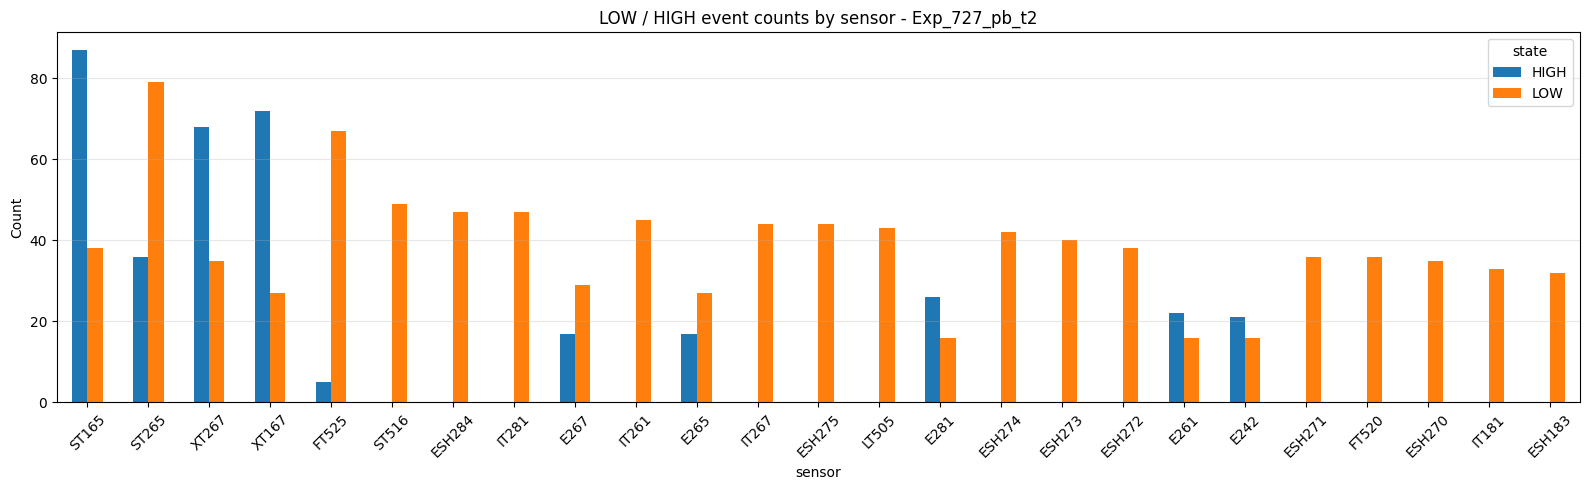

In [24]:
counts = (
    E.melt(var_name="sensor", value_name="state")
     .query("state in ['LOW', 'HIGH']")
     .groupby(["sensor", "state"])
     .size()
     .unstack(fill_value=0)
)

top_event_sensors = counts.sum(axis=1).sort_values(ascending=False).head(25).index
counts.loc[top_event_sensors].plot(kind="bar", figsize=(16, 5))
plt.title(f"LOW / HIGH event counts by sensor - {sc.scenario_id}")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 19) Quick comparison: one normal vs one faulty scenario

In [25]:
normal_ids = [s for s in scenario_ids if not scenario_is_faulty(s)]
faulty_ids = [s for s in scenario_ids if scenario_is_faulty(s)]

sid_n = normal_ids[0] if normal_ids else None
sid_f = faulty_ids[0] if faulty_ids else None

sid_n, sid_f

('Exp_727_pb_t2', 'Exp_732_pb_t2f')

In [26]:
compare_ids = [x for x in [sid_n, sid_f] if x is not None]
compare_frames = {}

for sid in compare_ids:
    sct = loader.load_scenario(sid)
    Xt = sct.X.copy().ffill().bfill()
    compare_frames[sid] = Xt

common_sensors = None
for sid, Xt in compare_frames.items():
    cols = set(Xt.columns)
    common_sensors = cols if common_sensors is None else common_sensors & cols

common_sensors = sorted(common_sensors) if common_sensors else []
common_sensors[:10], len(common_sensors)

(['E135',
  'E140',
  'E142',
  'E161',
  'E165',
  'E167',
  'E181',
  'E235',
  'E240',
  'E242'],
 83)

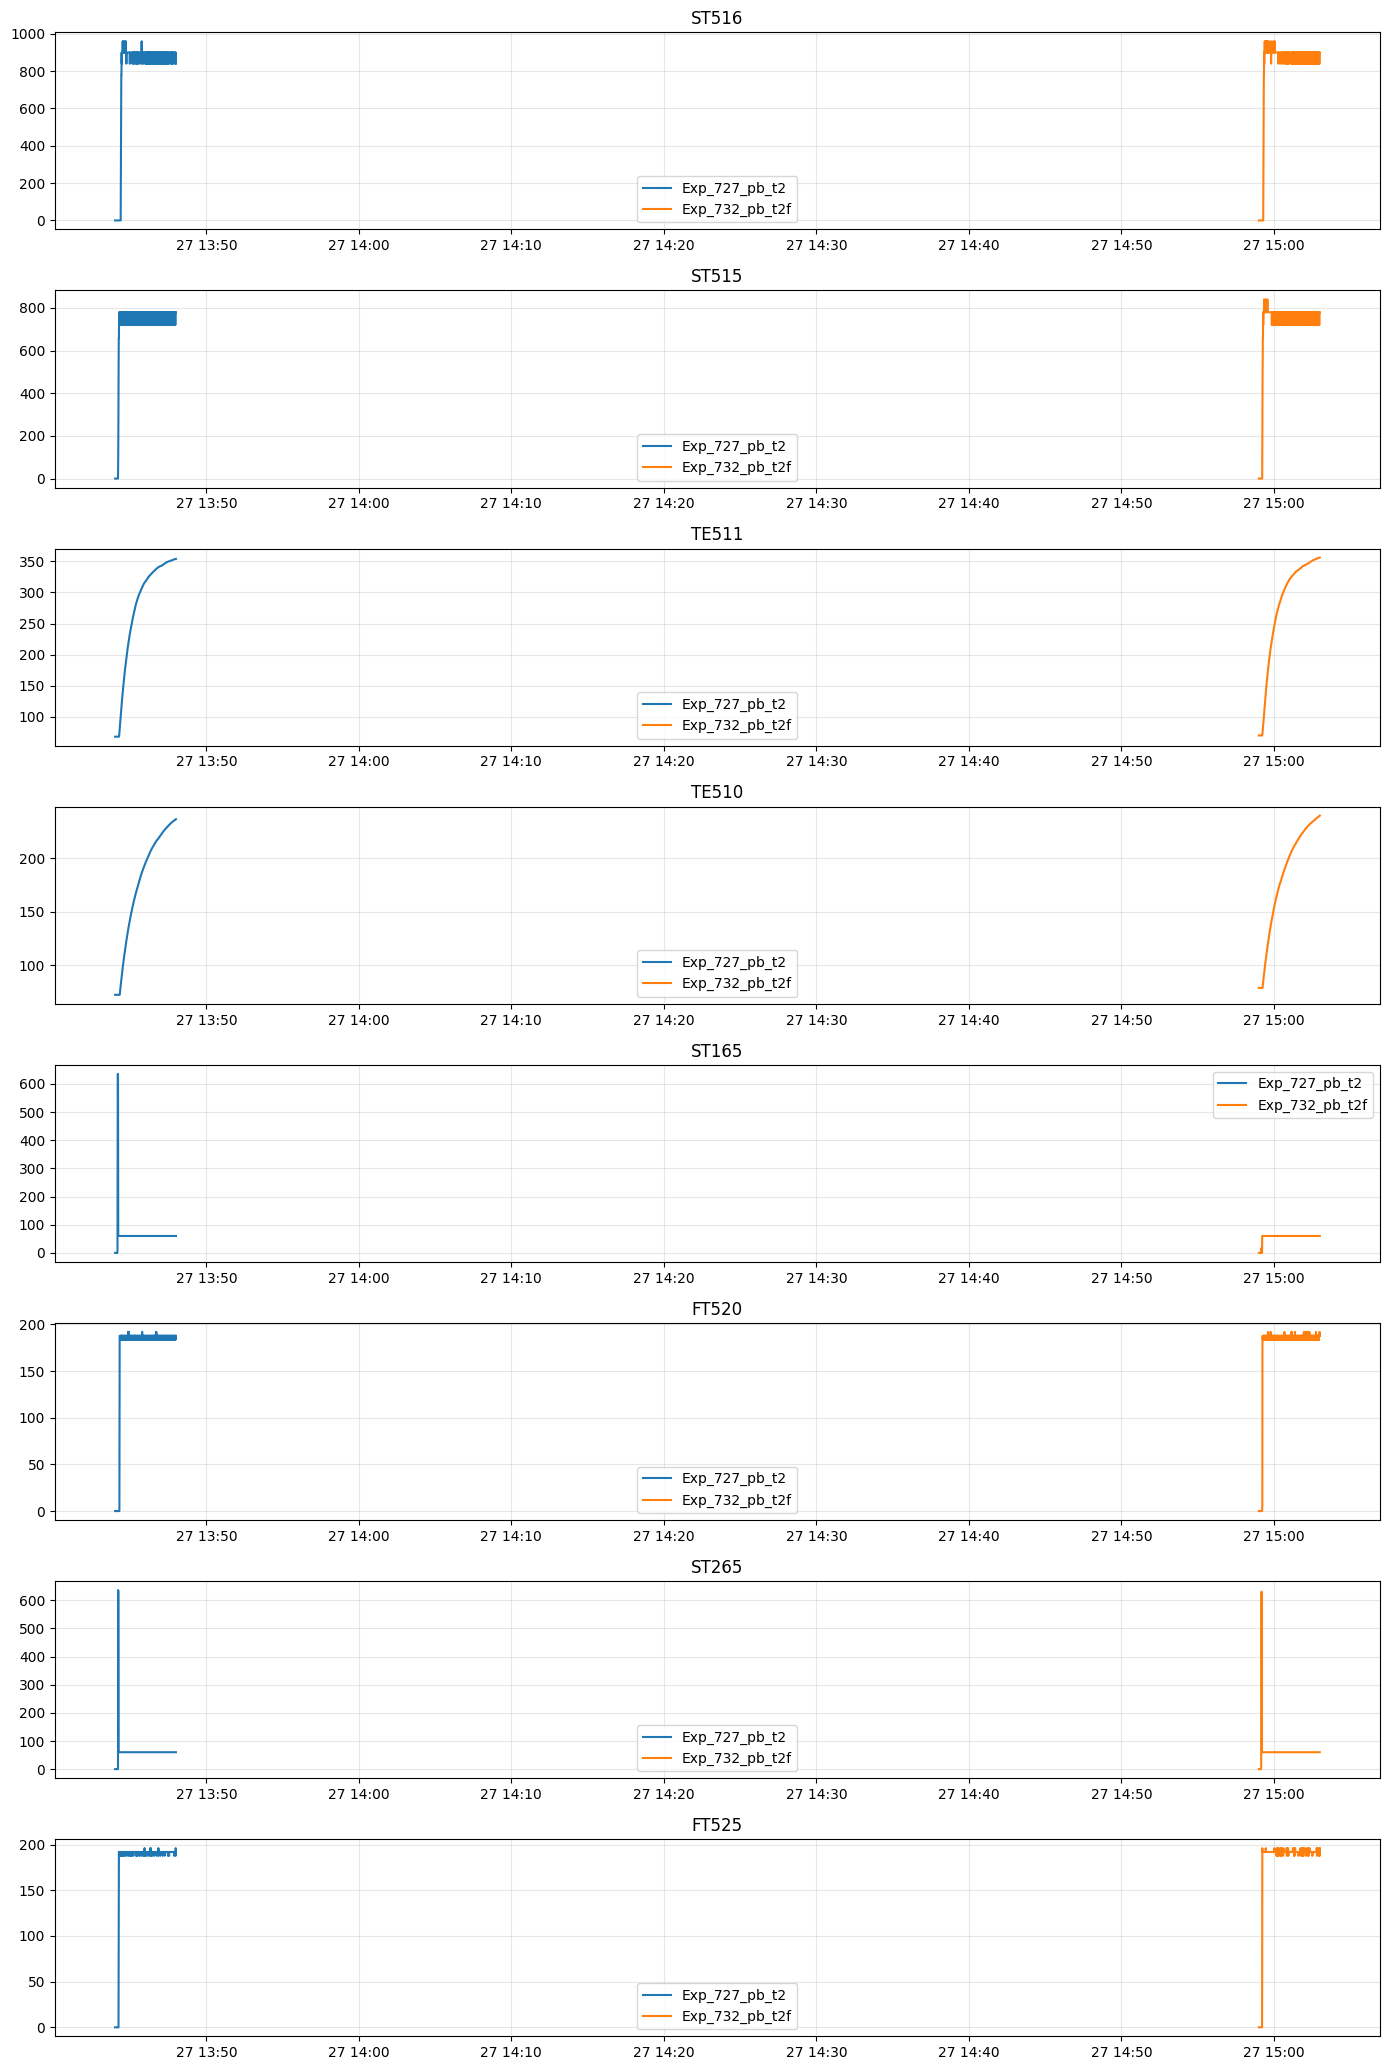

In [27]:
if compare_ids:
    sensor_pool = top_variable_sensors(compare_frames[compare_ids[0]][common_sensors], top_n=8)

    fig, axes = plt.subplots(len(sensor_pool), 1, figsize=(14, 2.6 * len(sensor_pool)), sharex=False)
    if len(sensor_pool) == 1:
        axes = [axes]

    for ax, sensor in zip(axes, sensor_pool):
        for sid in compare_ids:
            ax.plot(compare_frames[sid].index, compare_frames[sid][sensor], label=sid)
        ax.set_title(sensor)
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

## 20) Save summary tables

In [28]:
overview.to_csv("dxc09_overview.csv", index=False)
sensor_summary.to_csv("dxc09_sensor_summary.csv", index=False)
E.to_csv(f"evidence_{selected_scenario_id}.csv")

## Information in these plots

### Useful observations for Agent 1:
- sensors that are always constant across many normal scenarios may be **discrete/status channels**
- missingness patterns may be sensor-specific, not global
- some sensors may have naturally low variance and should not be treated as faulty flatlines
- correlation clusters can help define sensor groups for later sync checks
- baseline-zscore heatmaps help identify which sensors separate normal from faulty behavior

### Useful observations for Agent 2/3:
- top event sensors
- fault-sensitive mean shifts
- abrupt transition zones
- sensor groups that move together